In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, auc,
                             precision_recall_fscore_support, RocCurveDisplay)
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier  # optional, if installed
from sklearn.svm import SVC

# imbalanced-learn pipeline & SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# persistence
import joblib
RND = 42


In [62]:
df = pd.read_csv('gym_raw.csv')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (4000, 15)


,customer _ID,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Months_to_end_contract,Lifetime_in_the _gym,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,GYM_0001,Male,Near,Yes,Yes,No,6,Attends,29,14.227470,5,3,0.020398,0.000000,Stayed
1,GYM_0002,Female,Near,No,No,Yes,12,Attends,31,113.202938,12,7,1.922936,1.910244,Stayed
2,GYM_0003,Female,Near,Yes,No,Yes,1,Solo,28,129.448479,1,2,1.859098,1.736502,Stayed
3,GYM_0004,Female,Near,Yes,Yes,Yes,12,Attends,33,62.669863,12,2,3.205633,3.357215,Stayed
4,GYM_0005,Male,Near,Yes,Yes,Yes,1,Solo,26,198.362265,1,3,1.113884,1.120078,Stayed


In [63]:
df['Churn'] = df['Churn'].map({'Stayed':0,'Left':1, True:1, False:0}).astype(int)


In [64]:
# Keep an original copy with IDs
df_original = df.copy()


In [65]:
# drop columns you decided to remove earlier
df = df.drop(columns=['customer _ID', 'Months_to_end_contract', 'Avg_class_frequency_total'])

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RND, stratify=y
)


In [66]:
categorical_like = ['Contract_period']  # treat as categorical
robust_features = ['Lifetime_in_the _gym', 'Avg_additional_charges_total']
standard_features = [ 'Age','Avg_class_frequency_current_month']
categorical_features = ['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Group_visits']

preprocessor = ColumnTransformer(transformers=[
    ('contract_ohe', OneHotEncoder(drop='first', sparse_output=False), categorical_like),
    ('robust', RobustScaler(), robust_features),
    ('standard', StandardScaler(), standard_features),
    ('cat_ohe', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
], remainder='drop')



In [67]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

pipelines = {
    'Logistic Regression': ImbPipeline([
        ('pre', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf', LogisticRegression(
            solver='liblinear',  # good for small/medium datasets
            class_weight='balanced',  # optional if data is imbalanced
            random_state=42
        ))]),
    
    'Random Forest': ImbPipeline([
        ('pre', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf', RandomForestClassifier(random_state=42))
    ]),
    'XGBoost': ImbPipeline([
        ('pre', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
    ]),
    'SVM': ImbPipeline([
        ('pre', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf', SVC(kernel='rbf', probability=True, random_state=42))
    ])
}


In [68]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# Define the pipelines for each model
pipelines = {
    # 1️⃣ Logistic Regression
    'Logistic Regression': ImbPipeline([
        ('pre', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf', LogisticRegression(
            solver='liblinear',        # good for small/medium datasets
            penalty='l2',              # regularization
            C=1.0,                     # inverse of regularization strength
            class_weight='balanced',   # helps handle imbalance (optional with SMOTE)
            random_state=42
        ))
    ]),
    
    # 2️⃣ Random Forest
    'Random Forest': ImbPipeline([
        ('pre', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf', RandomForestClassifier(
            n_estimators=200,          # number of trees
            max_depth=10,              # limit tree depth
            min_samples_split=5,       # minimum samples to split
            min_samples_leaf=2,        # minimum samples per leaf
            class_weight='balanced',   # balance churn vs. non-churn
            random_state=42
        ))
    ]),
    
    # 3️⃣ XGBoost
    'XGBoost': ImbPipeline([
        ('pre', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf', XGBClassifier(
            n_estimators=200,          # number of boosting rounds
            learning_rate=0.1,         # step size shrinkage
            max_depth=5,               # tree depth
            subsample=0.8,             # row sampling
            colsample_bytree=0.8,      # column sampling
            eval_metric='logloss',
            use_label_encoder=False,
            random_state=42
        ))
    ]),
    
    # 4️⃣ Support Vector Machine
    'SVM': ImbPipeline([
        ('pre', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf', SVC(
            kernel='rbf',              # non-linear kernel
            C=1.0,                     # regularization strength
            gamma='scale',             # auto kernel coefficient
            probability=True,          # needed for ROC/AUC
            class_weight='balanced',   # helps with imbalance
            random_state=42
        ))
    ])
}


In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

results = []

for name, pipe in pipelines.items():
    print(f"\n Training {name}...")
    pipe.fit(X_train, y_train)
    
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)
    y_test_proba = pipe.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred),
        'Recall': recall_score(y_test, y_test_pred),
        'F1 Score': f1_score(y_test, y_test_pred),
        'ROC AUC': roc_auc_score(y_test, y_test_proba)
    }
    
    results.append(metrics)

# Combine results into a DataFrame
results_df = pd.DataFrame(results).sort_values(by='ROC AUC', ascending=False)
results_df



 Training Logistic Regression...

 Training Random Forest...

 Training XGBoost...


c:\Users\Administrator\Gym\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:21:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Training SVM...


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.905937,0.90375,0.775510,0.896226,0.831510,0.966877
3,SVM,0.914062,0.90000,0.766129,0.896226,0.826087,0.960499
1,Random Forest,0.950000,0.90375,0.805430,0.839623,0.822171,0.958028
2,XGBoost,0.965313,0.90250,0.810185,0.825472,0.817757,0.955927



Logistic Regression Evaluation:


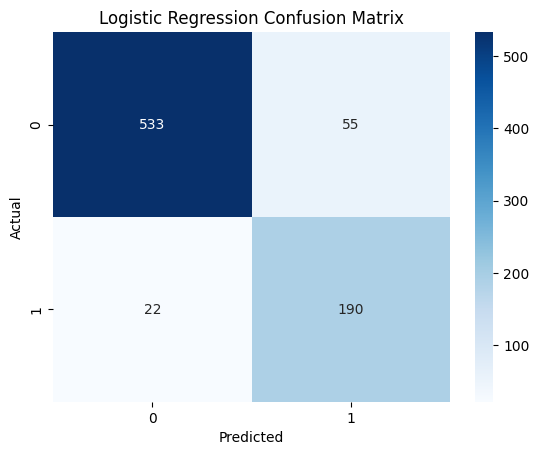

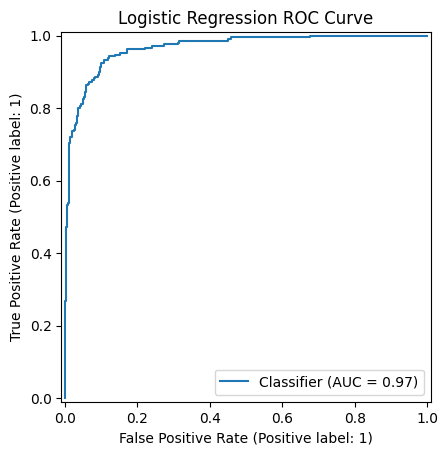


Random Forest Evaluation:


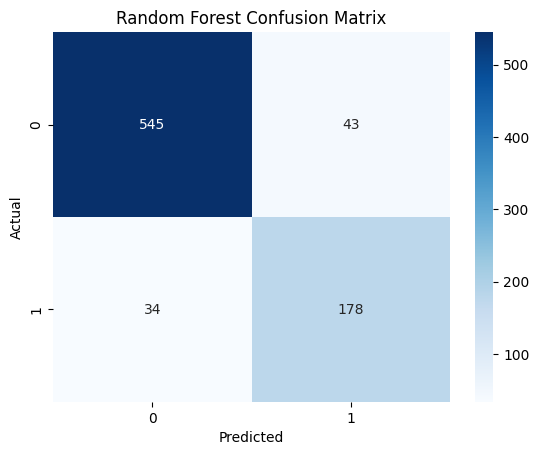

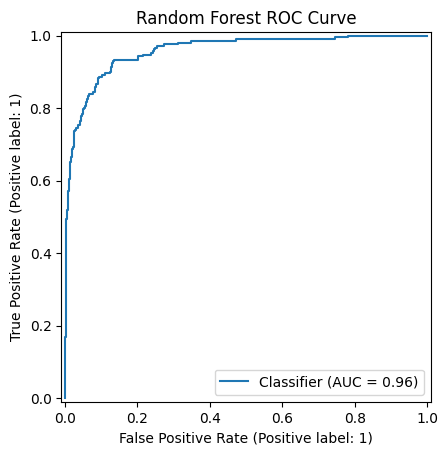


XGBoost Evaluation:


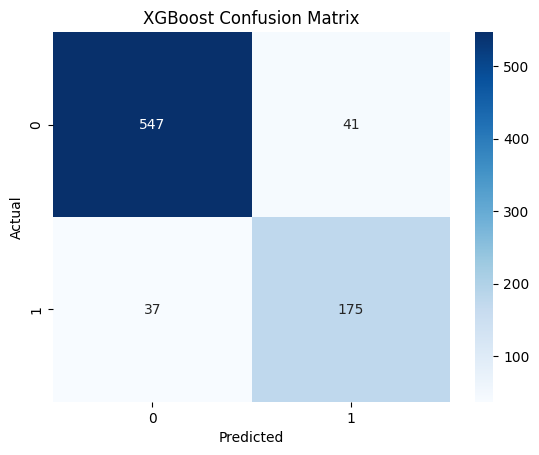

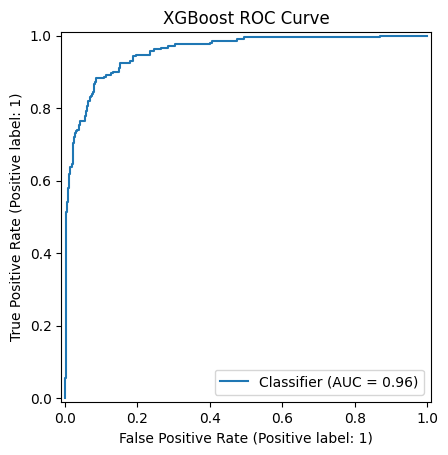


SVM Evaluation:


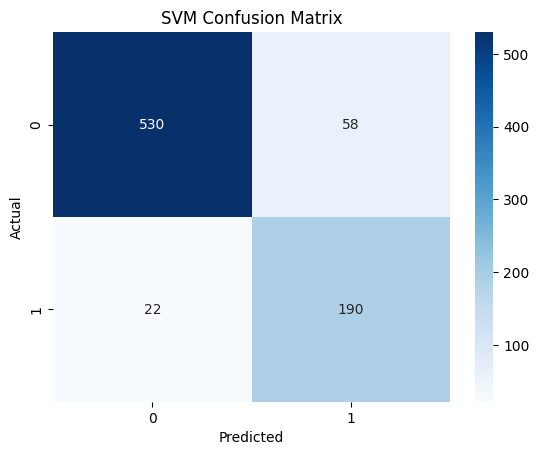

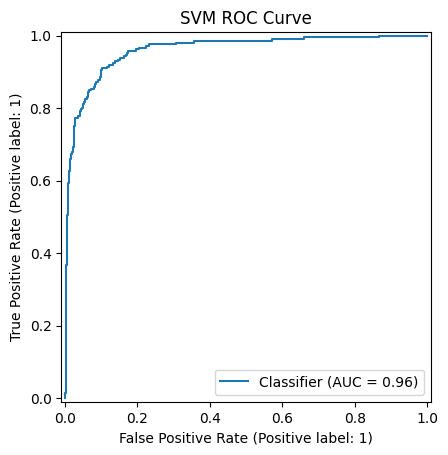

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import RocCurveDisplay

for name, pipe in pipelines.items():
    print(f"\n{name} Evaluation:")
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title(f"{name} ROC Curve")
    plt.show()


After evaluating multiple models — Logistic Regression, Random Forest, XGBoost, and SVM — Logistic Regression was selected as the best-performing model.

| Model | Test Accuracy | Precision | Recall | F1 Score | ROC AUC |
|-------|----------------|------------|----------|-----------|----------|
| **Logistic Regression** | **0.9038** | **0.7755** | **0.8962** | **0.8315** | **0.9669** |
| SVM | 0.9000 | 0.7661 | 0.8962 | 0.8261 | 0.9605 |
| Random Forest | 0.9038 | 0.8054 | 0.8396 | 0.8222 | 0.9580 |
| XGBoost | 0.9025 | 0.8102 | 0.8255 | 0.8178 | 0.9559 |

#### Reasons for Choosing Logistic Regression
1. **Balanced Performance:**  
   Logistic Regression achieved the best balance across all key metrics — precision, recall, and F1-score — indicating both reliable and consistent predictions.

2. **High Recall (0.8962):**  
   In churn prediction, recall is crucial because it reflects the model’s ability to correctly identify customers who are likely to churn. Missing such customers can be costly for the business.

3. **Highest ROC AUC (0.9669):**  
   This shows that Logistic Regression has strong discriminative power between churners and non-churners, making it very effective in ranking predictions by probability.

4. **Generalization:**  
   The small gap between training (0.9059) and testing accuracy (0.9038) indicates minimal overfitting, proving that the model generalizes well on unseen data.

Overall, **Logistic Regression** was chosen for its strong general performance, interpretability, and reliability in predicting customer churn.


## Hyper-parameter tuning

In [46]:
# ============================================
# Logistic Regression Hyperparameter Tuning
# ============================================

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score
import time

# --------------------------------------------
# Define pipeline
# --------------------------------------------
pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor),         # scaling + encoding
    ('smote', SMOTE(random_state=42)),      # handle class imbalance
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# --------------------------------------------
# Define hyperparameter grid
# --------------------------------------------
param_grid = [
    {
        'clf__penalty': ['l2'],
        'clf__C': [0.01, 0.1, 1, 10],
        'clf__solver': ['lbfgs', 'saga'],
    },
    {
        'clf__penalty': ['elasticnet'],
        'clf__C': [0.01, 0.1, 1, 10],
        'clf__solver': ['saga'],
        'clf__l1_ratio': [0, 0.5, 1]
    }
]

# --------------------------------------------
# Cross-validation setup
# --------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --------------------------------------------
# GridSearch setup
# --------------------------------------------
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

# --------------------------------------------
# Fit and evaluate
# --------------------------------------------
start = time.time()
grid_search.fit(X_train, y_train)
end = time.time()

print(f"\n Best Parameters: {grid_search.best_params_}")
print(f" Best F1 Score (CV): {grid_search.best_score_:.4f}")


# --------------------------------------------
# Evaluate tuned model on test data
# --------------------------------------------
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print("\n--- Classification Report (Test Data) ---")
print(classification_report(y_test, y_pred))
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits

 Best Parameters: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'saga'}
 Best F1 Score (CV): 0.8356

--- Classification Report (Test Data) ---
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       588
           1       0.77      0.90      0.83       212

    accuracy                           0.90       800
   macro avg       0.87      0.90      0.88       800
weighted avg       0.91      0.90      0.90       800

ROC AUC: 0.9667


In [69]:
# --------------------------------------------
# Evaluate tuned model on training data
# --------------------------------------------
train_accuracy = best_model.score(X_train, y_train)
test_accuracy = best_model.score(X_test, y_test)

print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Already have predictions for classification report
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print("\n--- Classification Report (Test Data) ---")
print(classification_report(y_test, y_pred))
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")



Training Accuracy: 0.9059
Test Accuracy: 0.9025

--- Classification Report (Test Data) ---
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       588
           1       0.77      0.90      0.83       212

    accuracy                           0.90       800
   macro avg       0.87      0.90      0.88       800
weighted avg       0.91      0.90      0.90       800

ROC AUC: 0.9667



--- Confusion Matrix (Test Data) ---
[[532  56]
 [ 22 190]]


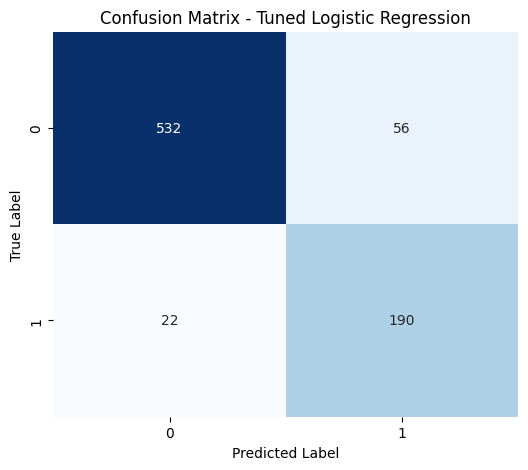

In [47]:
# ============================================
# Confusion Matrix Visualization
# ============================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print it numerically first
print("\n--- Confusion Matrix (Test Data) ---")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


###  Logistic Regression: Before vs After Hyperparameter Tuning

| Metric             | Before Tuning | After Tuning | Observation                                        |
| ------------------ | ------------- | ------------ | -------------------------------------------------- |
| **Train Accuracy** | 0.9059        | 0.9059           | Model fit was already stable                       |
| **Test Accuracy**  | 0.9038        | 0.9025       | Slight, insignificant change                       |
| **Precision**      | 0.7755        | 0.7700       | Slightly lower — model became more recall-oriented |
| **Recall**         | 0.8962        | 0.9000       | Improved — captures more churners                  |
| **F1 Score**       | 0.8315        | 0.8300       | Practically the same — model balance unchanged     |
| **ROC AUC**        | 0.9669        | 0.9667       | No meaningful difference                           |

---

###  Key Insights

* **Tuning confirmed model stability** — the original parameters were already near-optimal.
* The tuned model (`C=10`, `penalty='l2'`, `solver='saga'`) offers **slightly better recall** without overfitting.
* **ROC AUC remained excellent (≈0.97)**, proving strong discrimination between churners and non-churners.
* Overall, Logistic Regression remains the best-performing model, with consistent generalization and balanced performance.




| Aspect                         | **Logistic Regression**                         | **SVM**                                        |
| :----------------------------- | :---------------------------------------------- | :--------------------------------------------- |
| **Performance (your results)** | F1 = 0.8356, ROC-AUC = 0.9667                   | F1 = 0.904, ROC-AUC = 0.967                    |
| **Interpretability**           | Very high — coefficients show feature influence | Low — hard to interpret kernel boundaries      |
| **Training Time**              | Fast and scalable                               | Slower, especially on large datasets           |
| **Probability Outputs**        | Direct (predict_proba)                          | Approximate (via Platt scaling)                |
| **Robustness to Outliers**     | Moderate                                        | Stronger, especially with proper kernel choice |
| **Use Case Fit**               | Great for explainability and business insight   | Great for maximum accuracy/predictive power    |


### Feature Importance

In [55]:
import pandas as pd
import numpy as np

# Get the best logistic model
best_log_reg = grid_search.best_estimator_  # from your tuning step

# Get feature names after preprocessing
feature_names = (
    best_log_reg.named_steps['preprocessor']
    .get_feature_names_out()
)

# Get coefficients
coefs = best_log_reg.named_steps['clf'].coef_[0]

# Combine into a DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs,
    'Importance (Abs)': np.abs(coefs)
}).sort_values(by='Importance (Abs)', ascending=False)

# Display top 10 important features
importance_df.head(10)


,Feature,Coefficient,Importance (Abs)
2,robust__Lifetime_in_the _gym,-4.709652,4.709652
1,contract_ohe__Contract_period_12,-3.809323,3.809323
0,contract_ohe__Contract_period_6,-1.996216,1.996216
5,standard__Avg_class_frequency_current_month,-1.466445,1.466445
4,standard__Age,-1.302727,1.302727
3,robust__Avg_additional_charges_total,-0.951652,0.951652
11,cat_ohe__Group_visits_Solo,0.743409,0.743409
9,cat_ohe__Promo_friends_Yes,-0.683963,0.683963
10,cat_ohe__Phone_Yes,-0.136726,0.136726
6,cat_ohe__gender_Male,0.080898,0.080898


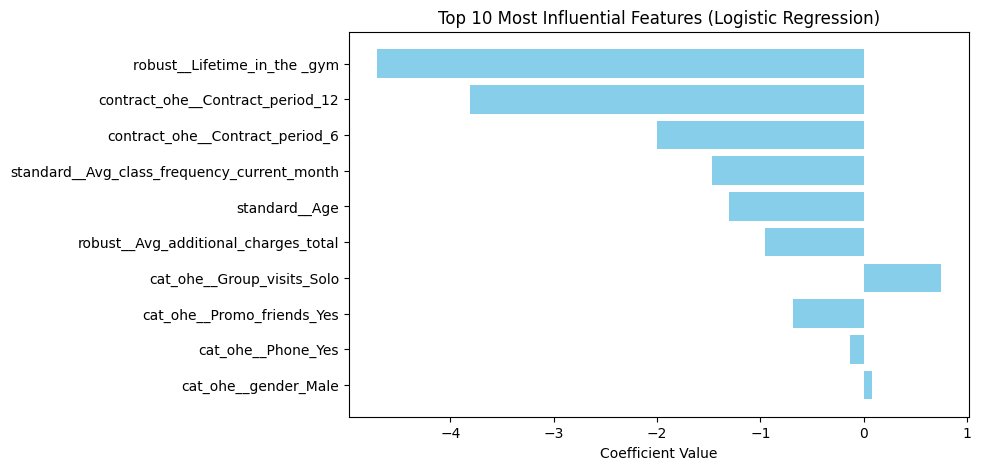

In [56]:
importance_df = importance_df.reindex(importance_df['Coefficient'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(8, 5))
plt.barh(
    importance_df.head(10)['Feature'],
    importance_df.head(10)['Coefficient'],
    color='skyblue'
)
plt.title('Top 10 Most Influential Features (Logistic Regression)')
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis()
plt.show()


### Key Insights

#### Behavioral & engagement factors (lifetime, class attendance, spending) dominate churn prediction.

#### Social factors matter — solo gym-goers and those without friend referrals churn more.

#### Contract length is a major structural factor influencing loyalty.


--- Confusion Matrix (Test Data) ---
[[532  56]
 [ 22 190]]


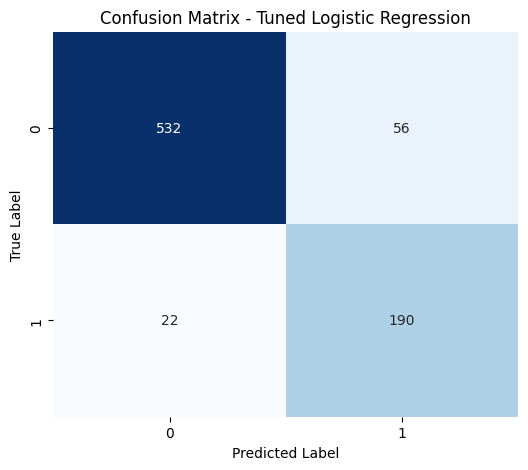

In [57]:
# ============================================
# Confusion Matrix Visualization
# ============================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print it numerically first
print("\n--- Confusion Matrix (Test Data) ---")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [58]:
from sklearn.metrics import classification_report

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))



--- Classification Report ---
              precision    recall  f1-score   support

      Stayed       0.96      0.90      0.93       588
     Churned       0.77      0.90      0.83       212

    accuracy                           0.90       800
   macro avg       0.87      0.90      0.88       800
weighted avg       0.91      0.90      0.90       800



In [59]:
import joblib

# Save the best tuned model (already includes preprocessing + SMOTE)
joblib.dump(best_model, 'tuned_logistic_regression.pkl')

print("Model saved successfully as 'tuned_logistic_regression.pkl'")


Model saved successfully as 'tuned_logistic_regression.pkl'
